<a href="https://colab.research.google.com/github/SandroBolkvadze/Facial-Expression-Recognition-Kaggle-Competition/blob/main/facial-expression-recognition-01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install dependencies

In [25]:
! pip install --upgrade kaggle wandb torchinfo --quiet

# Imports

In [26]:
import pandas as pd
import numpy as np

import torch
import torchvision.transforms as transforms
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import SGD, Adam
from torchinfo import summary

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from functools import partial

# Use GPU
USE_GPU = True
device = 'cuda' if USE_GPU and torch.cuda.is_available() else 'cpu'
print('Device available:', device)

Device available: cuda


# Mount Google Drive

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Copy Access Token

In [28]:
! mkdir ~/.kaggle
! cp /content/drive/MyDrive/kaggle/access_token ~/.kaggle/access_token
! chmod 600 ~/.kaggle/access_token

mkdir: cannot create directory ‘/root/.kaggle’: File exists


# Download Kaggle Competition Data

In [29]:
! kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge

challenges-in-representation-learning-facial-expression-recognition-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)


# Unzip Kaggle Competition Data

In [30]:
! unzip -o challenges-in-representation-learning-facial-expression-recognition-challenge

Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
  inflating: example_submission.csv  
  inflating: fer2013.tar.gz          
  inflating: icml_face_data.csv      
  inflating: test.csv                
  inflating: train.csv               


# Wandb Login

In [31]:
import wandb, os

with open('/content/drive/MyDrive/wandb/access_token') as file:
  token = file.read().strip()

os.environ['WANDB_API_KEY'] = token

! wandb login

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: sbolk23 (sbolk23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# Read & Transform Dataset

In [32]:
# Simple function for transforming 'pixels' elements
def pixels_to_image(pixels_str):
  pixels = np.array(pixels_str.split(), dtype=np.uint8)
  pixels = pixels.reshape(48, 48)
  return pixels

In [33]:
df = pd.read_csv('./icml_face_data.csv')

# Rename columns
df.columns = ['emotion', 'Usage', 'pixels']

# Choose Training part
df = df[df['Usage'] == 'Training']

# Drop 'Usage' column
df = df.drop(columns=['Usage'])

# Transform 'pixels' elements to numpy array in advance
df['pixels'] = df['pixels'].apply(pixels_to_image)


In [34]:
X = df.drop(columns=['emotion'])
y = df['emotion']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (28709, 1)
y shape: (28709,)


# Split Dataset

In [35]:
train_size = .7
val_size   = .15
test_size  = .15

# Split full dataset into train and val/test sets
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X, y,
    test_size=(val_size+test_size)/(train_size+val_size+test_size),
    stratify=y,
)

# Split val/test dataset into 50/50 val and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test,
    test_size=test_size/(val_size+test_size),
    stratify=y_val_test,
)

# Split full dataset into 70/15/15 train/val/test sets
print(f'X_train shape {X_train.shape} and y_train shape {y_train.shape}')
print(f'X_val shape {X_val.shape} and y_val shape {y_val.shape}')
print(f'X_test shape {X_test.shape} and y_test shape {y_test.shape}')

X_train shape (20096, 1) and y_train shape (20096,)
X_val shape (4306, 1) and y_val shape (4306,)
X_test shape (4307, 1) and y_test shape (4307,)


In [36]:
# Check if label distributions are same in train/val/test sets
y_train_dist = y_train.value_counts() / y_train.value_counts().sum()
y_val_dist   = y_val.value_counts()   / y_val.value_counts().sum()
y_test_dist  = y_test.value_counts()  / y_test.value_counts().sum()

# Should have roughly equal numbers across rows of 'emotions'
y_dist = pd.DataFrame({
    'y_train': y_train_dist,
    'y_val'  : y_val_dist,
    'y_test' : y_test_dist,
})

print(y_dist)

          y_train     y_val    y_test
emotion                              
3        0.251294  0.251277  0.251451
6        0.172920  0.173014  0.172974
4        0.168242  0.168137  0.168331
2        0.142715  0.142592  0.142791
0        0.139182  0.139108  0.139076
5        0.110470  0.110543  0.110286
1        0.015177  0.015327  0.015092


# Transform Raw Pixels

In [37]:
# Calculate mean pixel over whole train dataset
mean_pixel = X_train['pixels'].apply(np.mean).mean() / 255.0

# Transform 2d numpy pixel array
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(mean_pixel,), std=(1.0,)),
])

# Custom Image Dataset

In [38]:
class ImageDataset(Dataset):
  def __init__(self, X, y, transform=None):
    self.X = X
    self.y = torch.tensor(y.values)
    self.transform = transform

  def __len__(self):
    return self.X.shape[0]

  def __getitem__(self, index):
    image = self.X.iloc[index, 0]
    label = self.y[index]

    if self.transform:
      image = self.transform(image)

    return image, label

# Datasets

In [39]:
train_dataset = ImageDataset(X_train, y_train, transform)
val_dataset   = ImageDataset(X_val,   y_val,   transform)
test_dataset  = ImageDataset(X_test,  y_test,  transform)

# Train Epoch

In [40]:
def train_epoch(loader, model, criterion, optimizer):
  model.train()

  total_loss, correct, total = .0, 0, 0

  for t, (x, y) in enumerate(loader):
      x, y = x.to(device), y.to(device)

      # Zero out grads
      optimizer.zero_grad()

      # Calculate scores
      scores = model(x)

      # Calculate loss
      loss = criterion(scores, y)

      # Backpropagation
      loss.backward()

      # Update model parameters
      optimizer.step()

      with torch.no_grad():
        # Update Train stats
        _, preds    = scores.max(1)
        total_loss += loss.item()
        correct    += (preds == y).sum().item()
        total      += y.shape[0]

  return total_loss / len(loader), correct / total

# Check Accuracy & Loss

In [41]:
def evaluate(loader, model, criterion=None):
  model.eval()

  total_loss, correct, total = .0, 0, 0

  with torch.no_grad():
    for t, (x, y) in enumerate(loader):
      x, y = x.to(device), y.to(device)

      scores = model(x)
      _, preds = scores.max(1)

      if criterion:
        total_loss += criterion(scores, y).item()

      correct += (preds == y).sum().item()
      total   += len(y)

  return total_loss / len(loader), correct / total

# Early stopping

In [42]:
import copy

class EarlyStopper:
  def __init__(self, patience=1, min_delta=0):
    self.patience = patience
    self.min_delta = min_delta
    self.best_loss = np.inf
    self.early_stop = False
    self.best_weights = None
    self.best_epoch = -1
    self.counter = 0

  def __call__(self, epoch, val_loss, model):
    if val_loss < self.best_loss - self.min_delta:
      self.best_epoch = epoch
      self.best_loss = val_loss
      self.counter = 0
      self.best_weights = copy.deepcopy(model.state_dict())
    else:
      self.counter += 1
      if self.counter >= self.patience:
        self.early_stop = True

    return self.early_stop


# Train

In [84]:
def train(loader_train, loader_val, model, criterion, optimizer, epochs=10, early_stopper=None, use_wandb=False):
  history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

  for e in range(1, epochs + 1):

    # Train history
    train_loss, train_acc = train_epoch(loader_train, model, criterion, optimizer)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)

    # Validation history
    val_loss, val_acc = evaluate(loader_val, model, criterion)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Print statistics
    print('[Epoch %d / %d]' % (e, epochs,))
    print('train_loss: %.4f; train_acc: %.4f; val_loss: %.4f; val_acc: %.4f' % (train_loss, train_acc, val_loss, val_acc,))
    print()

    if use_wandb:
      wandb.log({
        'epoch':          e,
        'train_loss':     history['train_loss'][-1],
        'train_accuracy': history['train_acc'][-1],
        'val_loss':       history['val_loss'][-1],
        'val_accuracy':   history['val_acc'][-1],
      })

    if early_stopper and early_stopper(e, val_loss, model):
      model.load_state_dict(early_stopper.best_weights)
      print('Early stopping (Epoch: %d)' % early_stopper.best_epoch)


      if use_wandb:
        stopped_epoch = early_stopper.best_epoch
        wandb.summary['stopped_epoch']      = stopped_epoch
        wandb.summary['train_loss_at_best'] = history['train_loss'][stopped_epoch]
        wandb.summary['train_acc_at_best']  = history['train_acc'][stopped_epoch]
        wandb.summary['best_val_loss']      = history['val_loss'][stopped_epoch]
        wandb.summary['best_val_acc']       = history['val_acc'][stopped_epoch]

      break

  return history

# Two Layer FC

In [44]:
class TwoLayerFC(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, config=None):
    super().__init__()
    config = config if config is not None else {}

    # Initialize Layers
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(input_size, hidden_size)
    self.fc2 = nn.Linear(hidden_size, output_size)

    act_cls = config.get('activation', None)
    self.act = act_cls() if act_cls is not None else nn.ReLU()

    # Normalization layer
    norm_cls = config.get('norm', None)
    self.norm = norm_cls(hidden_size) if norm_cls is not None else None

    # Dropout laye
    dropout_p = config.get('dropout', None)
    self.dropout = nn.Dropout(dropout_p) if dropout_p is not None else None

    # Initialize weights & biases
    fc1_init = config.get('fc1_init', partial(nn.init.kaiming_normal_, nonlinearity='relu'))
    fc2_init = config.get('fc2_init', nn.init.xavier_normal_)

    fc1_init(self.fc1.weight)
    fc2_init(self.fc2.weight)

    nn.init.zeros_(self.fc1.bias)
    nn.init.zeros_(self.fc2.bias)

  def forward(self, x):
    # Flatten input
    x = self.flatten(x)

    # Linear
    x = self.fc1(x)

    # Norm
    if self.norm is not None:
      x = self.norm(x)

    # Activation
    if self.act is not None:
      x = self.act(x)

    # Dropout
    if self.dropout is not None:
      x = self.dropout(x)

    # Linear
    x = self.fc2(x)

    return x

# Check: Loss is reasonable for untrained model

In [45]:
# Create Train DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Create model, criterion, optimizer
model     = TwoLayerFC(48*48, 64, 7).to(device)
criterion = nn.CrossEntropyLoss()

model.eval()

loss, _ = evaluate(train_loader, model, criterion)
print('Loss: %.4f' % loss)

Loss: 1.9418


# Check: Model can overfit small data

In [46]:
# Create small data
small_data_size = 32

X_small_train, y_small_train = X_train[:small_data_size], y_train[:small_data_size]

small_dataset = ImageDataset(X_small_train, y_small_train, transform)
small_loader  = DataLoader(small_dataset, batch_size=small_data_size, shuffle=True)

In [47]:
# Create model, criterion, optimizer
model     = TwoLayerFC(48*48, 1, 7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = SGD(model.parameters(), lr=1e-2, weight_decay=1e-6)

# Train model
history = train(small_loader, small_loader, model, criterion, optimizer, epochs=1)

train_loss: 1.9619; train_acc: 0.1250; val_loss: 1.9594; val_acc: 0.1562



## Check: Loss vs Acc

In [49]:
sample_size = 64

# Fixed batch
X_fixed   = X_train.sample(sample_size)
y_fixed   = y_train[X_fixed.index]
fixed_loader = DataLoader(ImageDataset(X_fixed, y_fixed, transform), batch_size=sample_size, shuffle=False)

# Create model, criterion, optimizer
model     = TwoLayerFC(48*48, 32, 7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = SGD(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Train model
for i in range(50):
    print(f'[Epoch {i+1} / 50]')
    X_sample = X_train.sample(sample_size)
    y_sample = y_train[X_sample.index]

    sample_dataset = ImageDataset(X_sample, y_sample, transform)
    sample_loader  = DataLoader(sample_dataset, batch_size=sample_size, shuffle=True)

    train(sample_loader, fixed_loader, model, criterion, optimizer, epochs=1)

[Epoch 1 / 50]
train_loss: 2.0288; train_acc: 0.0938; val_loss: 2.0404; val_acc: 0.1406

[Epoch 2 / 50]
train_loss: 2.0185; train_acc: 0.1250; val_loss: 2.0395; val_acc: 0.1406

[Epoch 3 / 50]
train_loss: 2.0233; train_acc: 0.1250; val_loss: 2.0381; val_acc: 0.1406

[Epoch 4 / 50]
train_loss: 2.0202; train_acc: 0.1250; val_loss: 2.0373; val_acc: 0.1406

[Epoch 5 / 50]
train_loss: 2.0442; train_acc: 0.1094; val_loss: 2.0363; val_acc: 0.1406

[Epoch 6 / 50]
train_loss: 2.0168; train_acc: 0.2031; val_loss: 2.0356; val_acc: 0.1406

[Epoch 7 / 50]
train_loss: 2.0015; train_acc: 0.0625; val_loss: 2.0348; val_acc: 0.1406

[Epoch 8 / 50]
train_loss: 2.0480; train_acc: 0.0938; val_loss: 2.0337; val_acc: 0.1406

[Epoch 9 / 50]
train_loss: 2.0754; train_acc: 0.1094; val_loss: 2.0325; val_acc: 0.1406

[Epoch 10 / 50]
train_loss: 2.0375; train_acc: 0.0781; val_loss: 2.0316; val_acc: 0.1406

[Epoch 11 / 50]
train_loss: 2.0287; train_acc: 0.0938; val_loss: 2.0310; val_acc: 0.1406

[Epoch 12 / 50]
tra

# Check: Activation statistics are reasonable

## Create hooks

In [50]:
# Activation hook
def get_activation(layer_name, activations):
  def hook(module, input, output):
      activations.append({'layer_name': layer_name, 'layer': module, 'out': output.detach()})
  return hook

# Gradient hook
def get_gradient(layer_name, gradients):
  def hook(module, grad_input, grad_output):
      gradients.append({'layer_name': layer_name, 'layer': module, 'out': grad_output[0].detach()})
  return hook

## Attach hooks to model

In [51]:
# Create model
model = TwoLayerFC(
    48*48, 64, 7,
    config={
        'activation': nn.Tanh,
        'fc1_init': partial(nn.init.normal_, mean=0, std=1),
        'fc2_init': partial(nn.init.normal_, mean=0, std=1),
        # 'norm': nn.LayerNorm,
    },
).to(device)

# Set model to train mode
model.train()

# Summary of model
print(summary(model))

# Register hooks on model layers
activations = []
gradients   = []
hooks       = []

for layer_name, layer in model.named_modules():
  if isinstance(layer, (nn.Linear, nn.ReLU, nn.Tanh, nn.Sigmoid, nn.LeakyReLU, nn.LayerNorm, nn.BatchNorm1d)):
    hooks.append(layer.register_forward_hook(get_activation(layer_name, activations)))
    hooks.append(layer.register_full_backward_hook(get_gradient(layer_name, gradients)))

Layer (type:depth-idx)                   Param #
TwoLayerFC                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            147,520
├─Linear: 1-3                            455
├─Tanh: 1-4                              --
Total params: 147,975
Trainable params: 147,975
Non-trainable params: 0


## Run data through model

In [52]:
# Sample unit Gaussian input
batch = torch.randn(1000, 1, 48, 48, requires_grad=True).to(device)

# Sample random labels for 7 classes
labels = torch.randint(0, 7, (1000,)).to(device)

# Forwad and Backward passes
scores = model(batch)
loss = nn.CrossEntropyLoss()(scores, labels)
loss.backward()

# Remove hooks
for h in hooks:
  h.remove()

## Plot activations and gradients

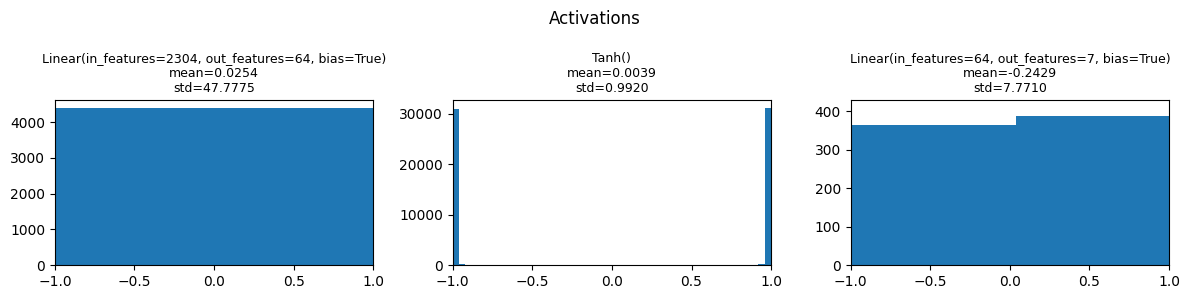

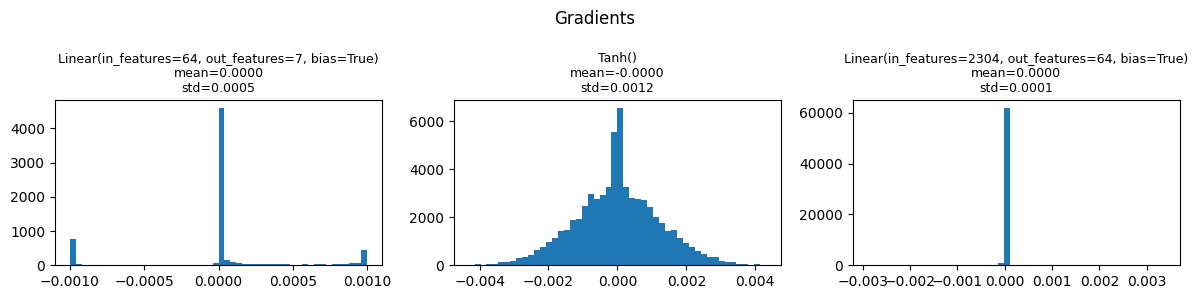

In [53]:
def plot_histograms(data, title, xlim=None):
    n = len(data)
    fig, axes = plt.subplots(1, n, figsize=(n * 4, 3))
    if n == 1: axes = [axes]

    for ax, item in zip(axes, data):
        out = item['out']
        ax.hist(out.cpu().numpy().flatten(), bins=50)
        ax.set_title(f'{item["layer"]}\nmean={out.mean():.4f}\nstd={out.std():.4f}', fontsize=9)
        if xlim:
          ax.set_xlim(xlim)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_histograms(activations, 'Activations', (-1, 1))
plot_histograms(gradients,   'Gradients')

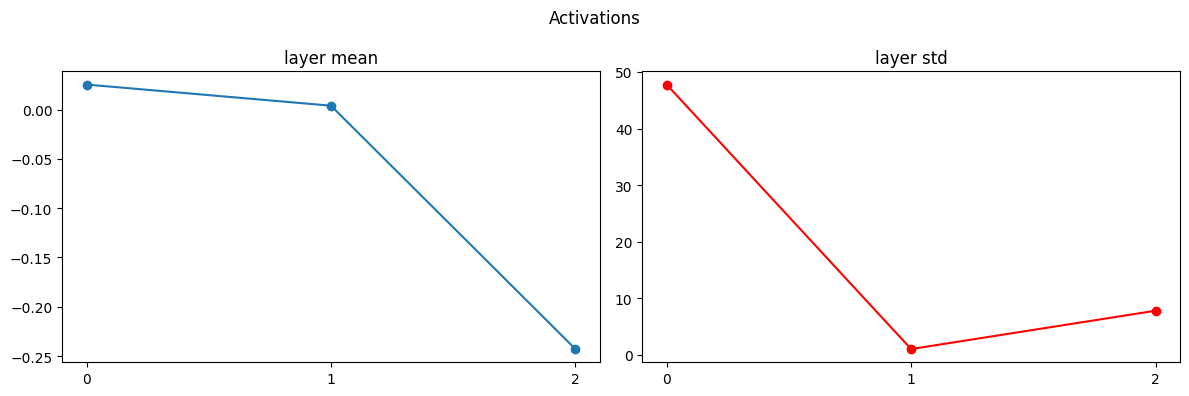

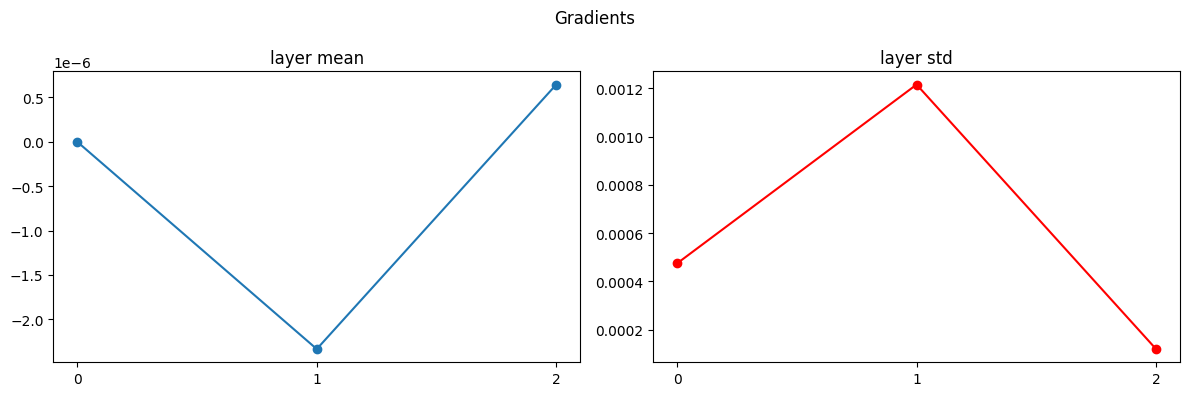

In [54]:
def plot_mean_std(data, title):
  names = [d['layer'] for d in data]
  means = [d['out'].mean().item() for d in data]
  stds  = [d['out'].std().item()  for d in data]

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

  ax1.plot(means, marker='o')
  ax1.set_xticks(range(len(names)))
  ax1.set_title('layer mean')

  ax2.plot(stds, marker='o', color='red')
  ax2.set_xticks(range(len(names)))
  ax2.set_title('layer std')

  plt.suptitle(title)
  plt.tight_layout()
  plt.show()

plot_mean_std(activations, 'Activations')
plot_mean_std(gradients,   'Gradients')

# Train TwoLayerFC model

## Registry

In [55]:
REGISTRY = {
    'act':              {'ReLU': nn.ReLU, 'Tanh': nn.Tanh, 'GELU': nn.GELU, 'LeakyReLU': nn.LeakyReLU, 'Sigmoid': nn.Sigmoid},
    'norm':             {'Batchnorm': nn.BatchNorm1d, 'Layernorm': nn.LayerNorm, None: None},
    'optim':            {'Adam': Adam, 'SGD': SGD},
    'arch':             {'TwoLayerFC': TwoLayerFC},
    'loss':             {'CrossEntropyLoss': nn.CrossEntropyLoss},
    'weights_init': {
        'kaiming_normal':  nn.init.kaiming_normal_,
        'kaiming_uniform': nn.init.kaiming_uniform_,
        'xavier_normal':   nn.init.xavier_normal_,
        'xavier_uniform':  nn.init.xavier_uniform_,
        'normal':          nn.init.normal_,
        'orthogonal':      nn.init.orthogonal_,
        'zeros':           nn.init.zeros_,
    },
}

## Build experiment from config

In [56]:
def resolve(config, conf_key, reg_key, default=None):
  if conf_key not in config:
    return default

  kwargs = config.get(f'{conf_key}_kwargs', {})
  return partial(REGISTRY[reg_key][config[conf_key]], **kwargs)

def build_experiment(config):
  model = REGISTRY['arch'][config['architecture']](
      config['input_size'],
      config['hidden_size'],
      config['output_size'],
      config={
          'activation': resolve(config, 'activation', 'act'),
          'norm':       resolve(config, 'norm', 'norm'),
          'dropout':    config.get('dropout', None),
          'fc1_init':   resolve(config, 'weights_init', 'weights_init', partial(nn.init.kaiming_normal_, nonlinearity='relu')),
          'fc2_init':   resolve(config, 'weights_init', 'weights_init', partial(nn.init.xavier_normal_)),
      }
  ).to(device)

  criterion = resolve(config, 'loss_function', 'loss')()
  optimizer = resolve(config, 'optimizer', 'optim')(model.parameters())

  early_stopper = EarlyStopper(config['patience'], config['min_delta']) if config['early_stop'] else None

  return model, criterion, optimizer, early_stopper


## Build model name from config

In [77]:
def format_kwargs(kwargs):
    return '_'.join(f'{k}_{v}' for k, v in kwargs.items())

def build_name(config):
    opt_kwargs = config.get('optimizer_kwargs', {})
    parts = [
        config['architecture'],
        f'bs_{config['batch_size']}__'
        f'hs_{config["hidden_size"]}',
    ]

    for key in ['activation', 'optimizer', 'norm', 'dropout', 'weights_init', 'early_stop']:
        if config.get(key):
            part = f'{key}_{config[key]}'
            kwargs = config.get(f'{key}_kwargs', {})
            if kwargs:
                part += f'_{format_kwargs(kwargs)}'
            parts.append(part)

    return '__'.join(parts)

In [82]:
config={
    'epochs': 100,
    'batch_size': 64,
    'architecture': 'TwoLayerFC',
    'input_size': 48*48,
    'hidden_size': 64,
    'output_size': 7,
    'loss_function': 'CrossEntropyLoss',
    'optimizer': 'Adam',
    'optimizer_kwargs': {'lr': 1e-3, 'weight_decay': 0,},
    'activation': 'Tanh',
    'weights_init': 'xavier_normal',
    # 'weights_init_kwargs': {'mean': 0, 'std':1},
    'early_stop': False,
    # 'early_stop_kwargs': {'patience': 20, 'min_delta': 0}
    # 'norm': 'Layernorm'
}

name = build_name(config)
print(name)

# Wandb init
run = wandb.init(
    project='Facial_Expression_Recognition_01',
    name=name,
    config=config
)

TwoLayerFC__bs_64__hs_64__activation_Tanh__optimizer_Adam_lr_0.001_weight_decay_0__weights_init_xavier_normal


In [83]:
# Create Train and Validation DataLoaders
train_loader = DataLoader(train_dataset,  batch_size=config['batch_size'], shuffle=True)
val_loader   = DataLoader(val_dataset,    batch_size=config['batch_size'], shuffle=False)

model, criterion, optimizer, early_stopper = build_experiment(config)

print(summary(model))

# Init wandb
wandb.watch(model, log='all')

# history = train(train_loader, val_loader, model, criterion, optimizer, epochs=config['epochs'], early_stopper=early_stopper, use_wandb=False)

# Train model
history = train(train_loader, val_loader, model, criterion, optimizer, epochs=config['epochs'], early_stopper=early_stopper, use_wandb=True)

# Save model
torch.save(model.state_dict(), f'Facial_Expression_Recognition_01_TwoLayerFC_{wandb.run.id}.pth')
wandb.save(f'Facial_Expression_Recognition_01_TwoLayerFC_{wandb.run.id}.pth')

# Finish wandb
wandb.finish()

Layer (type:depth-idx)                   Param #
TwoLayerFC                               --
├─Flatten: 1-1                           --
├─Linear: 1-2                            147,520
├─Linear: 1-3                            455
├─Tanh: 1-4                              --
Total params: 147,975
Trainable params: 147,975
Non-trainable params: 0
train_loss: 1.7340; train_acc: 0.3249; val_loss: 1.6926; val_acc: 0.3360

train_loss: 1.6133; train_acc: 0.3812; val_loss: 1.6564; val_acc: 0.3556

train_loss: 1.5580; train_acc: 0.4028; val_loss: 1.6192; val_acc: 0.3755

train_loss: 1.5164; train_acc: 0.4204; val_loss: 1.6115; val_acc: 0.3881

train_loss: 1.4719; train_acc: 0.4429; val_loss: 1.6069; val_acc: 0.3843

train_loss: 1.4369; train_acc: 0.4568; val_loss: 1.6061; val_acc: 0.3839

train_loss: 1.4056; train_acc: 0.4731; val_loss: 1.6184; val_acc: 0.3823

train_loss: 1.3684; train_acc: 0.4856; val_loss: 1.6162; val_acc: 0.3876

train_loss: 1.3347; train_acc: 0.5028; val_loss: 1.6393; val_

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


train_loss: 0.1205; train_acc: 0.9720; val_loss: 4.1115; val_acc: 0.3748



epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇███
train_accuracy,▁▁▁▂▂▂▃▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████
train_loss,█▇▇▇▇▅▅▅▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁█▇▇▇█▇▇▆▇▅▆▇▆▅▄▆▃▅▅▅▆▄▄▅▅▅▆▆▄▅▄▄▆▄▇▄▄▄▆
val_loss,▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇██
epoch,100
train_accuracy,0.97203
train_loss,0.1205
val_accuracy,0.37483
val_loss,4.11154


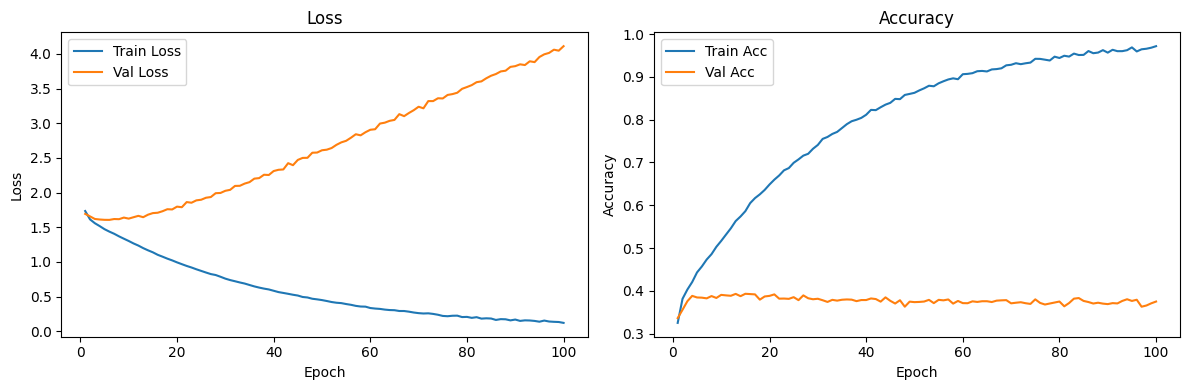

In [85]:
def plot_history(train_loss, train_acc, val_loss, val_acc):
    epochs = range(1, len(train_loss) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    ax1.plot(epochs, train_loss, label='Train Loss')
    ax1.plot(epochs, val_loss, label='Val Loss')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Accuracy
    ax2.plot(epochs, train_acc, label='Train Acc')
    ax2.plot(epochs, val_acc, label='Val Acc')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_history(history['train_loss'], history['train_acc'], history['val_loss'], history['val_acc'])

In [ ]:
100